#### Phase retrieval optimisation
See which pupil masks help optmise info on pupil plane aberrations, 
taking into account covariance with mask rotation. 

Note: 

In [1]:
import dLux as dl
import dLux.utils as dlu

import jax.numpy as jnp
import numpy as np
import jax.random as jr
import jax.scipy as jsp
from jax import vmap
import jax

jax.config.update("jax_enable_x64", True)
jax.config.update("jax_debug_nans", False)
jax.config.update("jax_disable_jit", False)

import zodiax as zdx
import optax
from tqdm.notebook import tqdm

# from tqdm import tqdm

from skimage.io import imread
from skimage.filters import window
import skimage as ski
from skimage.transform import resize

import matplotlib.pyplot as plt
from matplotlib.colors import PowerNorm, CenteredNorm
import matplotlib.colors as mcolors

from src.PhaseRetrieval import (
    OptimManager,
    JointOptimManager,
    PointSource,
    TransmissiveLayer,
    DynamicAperture,
)
from src.uv import dummy_splodge_mask, compute_complex_vis, UVComponents

import os
import pickle

import numpyro as npy
import numpyro.distributions as dist
from jax import device_count
import chainconsumer as cc
import pandas as pd

Init models

In [2]:
# ------- Physical Parameters ---------------------------------------------------------------------#
aperture_npix = 512  # Number of pixels across the aperture
aperture_diameter = 122e-3  # (m) slightly smaller for mask cap
spider_width = 20e-3  # Spider width (m)
spider_angle = (
    270  # Spider angle (degrees), clockwise, 0 is spider pointing vertically up
)
coords = dlu.pixel_coords(npixels=aperture_npix, diameter=aperture_diameter)
circle = dlu.circle(coords=coords, radius=aperture_diameter / 2)

# Observations wavelengths (bandpass of 530-640nm)
red_laser_wl = 635e-09  # for laser data
green_laser_wl = 520e-09  # for laser data
wf_npixels = aperture_npix  # Number of pixels across the wavefront
wf_diam = aperture_diameter  # Diameter of initial wavefront to propagate wavefront (m)

# Detector parameters (BFS-U3-200S6-BD)
BFS_px_sep = 2.4e-6 * 1e3  # pixel separation (mm)
f_det = 1338  # 1300#1350                    # Focal length from OAP2 to detector (mm)
px_ang_sep = 2 * np.arctan((BFS_px_sep / 2) / f_det)  # angular sep between pixels (rad)

# Simulated Detector
psf_npix = 40  # Number of pixels along one dim of the PSF
psf_hlf_sz = int(psf_npix / 2)  # half window sz of cropped data
oversample = 1  # Oversampling factor for the PSF
psf_pixel_scale = dlu.rad2arcsec(
    px_ang_sep
)  # arcsec (to match detector plate scale) 80e-4

In [3]:
# Define non-linear detector response
class ApplyBFSPixelResponse(dl.layers.detector_layers.DetectorLayer):
    """
    Applies a pixel response array to the input psf, via a multiplication. This can be
    used to model variations in the inter and intra-pixel sensitivity variations common
    to most detectors.

    We have characterised the BFS detector to have a gamma curve gain response per px.

    ??? abstract "UML"
        ![UML](../../assets/uml/ApplyPixelResponse.png)

    Attributes
    ----------
    pixel_response : Array
        The pixel_response to apply to the input psf in the form of gamma fn coeffs:
        measured_intensity = alpha + beta*real_intensity^gamma
        with    pixel_response[0] = alpha
                pixel_response[1] = beta
                pixel_response[2] = gamma
    luminance_min, luminance_max : float
        The minimum and maximum input luminance values for the pixel response (with which the
        gamma curve was characterised).
    intensity_min, intensity_max : float
        The minimum and maximum output intensity values for the pixel response (with which the
        gamma curve was characterised).
    """

    pixel_response: jnp.array

    def __init__(
        self: dl.layers.detector_layers.DetectorLayer,
        pixel_response: jnp.array,
    ):
        """
        Parameters
        ----------
        pixel_response : Array
            The pixel_response to apply to the input psf. Must be a 2-dimensional array
            equal to size of the psf at time of application.
        """
        super().__init__()

        self.pixel_response = jnp.asarray(pixel_response, dtype=float)

    def apply(self: dl.layers.detector_layers.DetectorLayer, psf: dl.PSF) -> dl.PSF:
        """
        Applies the layer to the PSF.

        Parameters
        ----------
        psf : PSF
            The psf to operate on.

        Returns
        -------
        psf : PSF
            The transformed psf.

        """
        psf_array = jnp.asarray(psf.data, dtype=float)

        # todo this properly: need to normalise then apply then reset range (easiest way to do without converting cd/m2 to photons)
        # psf_array = self.pixel_response[0] + self.pixel_response[1]*psf_array**(self.pixel_response[2])

        psf_obj = dl.PSF(data=psf_array**0.8, pixel_scale=psf.pixel_scale)
        # psf_obj = dl.PSF(data = psf_array, pixel_scale = psf.pixel_scale)

        return psf_obj

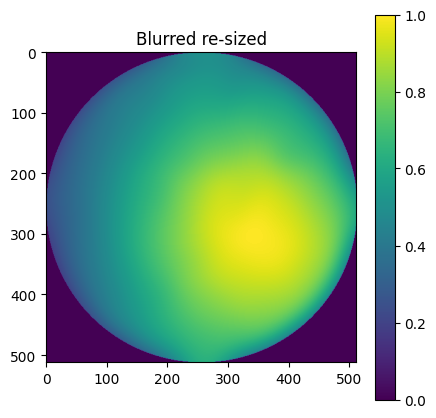

In [5]:
intensity_dist = jnp.load("data/intensity/26_01_09.npy")
plt.figure(figsize=(5, 5))
plt.title("Blurred re-sized")
plt.imshow(intensity_dist)
plt.colorbar()

Text(0.5, 1.0, 'Spider 180')

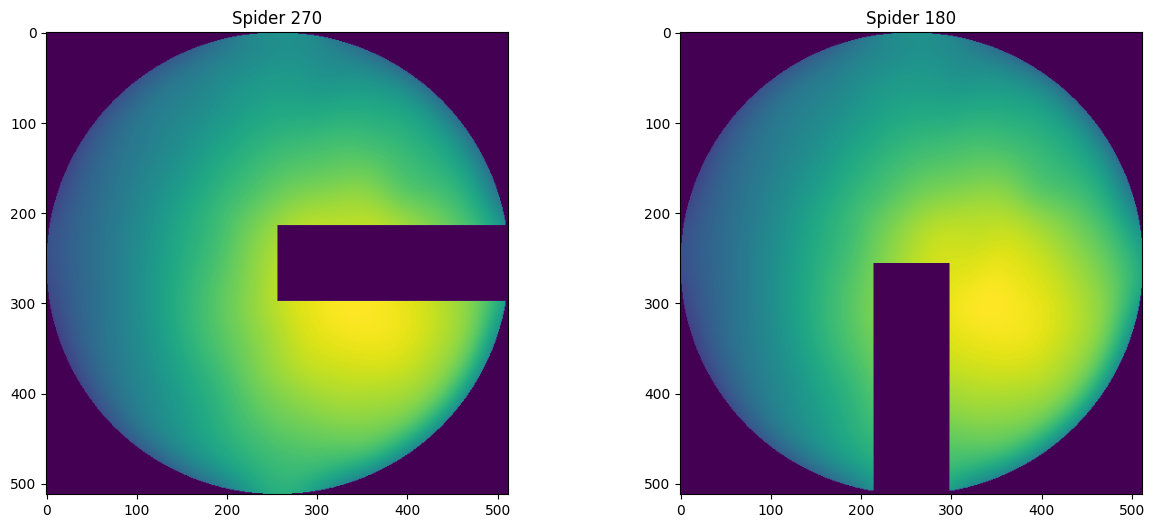

In [6]:
# Zernike aberrations
zernike_indicies = jnp.arange(4, 21)
coeffs = jnp.zeros(zernike_indicies.shape)
basis = dlu.zernike_basis(
    js=zernike_indicies, coordinates=coords, diameter=aperture_diameter
)

optical_systems = []
transmissions = []

red_src = PointSource(wavelengths=[red_laser_wl], flux=jnp.asarray([1e13], dtype=float))

spider_angles = [
    270,
    180,
]  # 0deg is spider pointing vertically up, rotates CW from 0deg
optical_systems = []
transmissions = []
for i in range(len(spider_angles)):
    spider = dlu.spider(coords=coords, width=spider_width, angles=[spider_angles[i]])
    transmission = dlu.combine([circle, spider])

    layers = [
        (
            "intensity",
            dl.layers.TransmissiveLayer(transmission=intensity_dist, normalise=False),
        ),
        (
            "spider",
            TransmissiveLayer(transmission=transmission, normalise=False),
        ),  # rotable spider
        (
            "aperture",
            dl.layers.BasisOptic(
                basis=basis, transmission=None, coefficients=coeffs, normalise=False
            ),
        ),
    ]

    optics = dl.AngularOpticalSystem(
        wf_npixels=wf_npixels,
        diameter=wf_diam,
        layers=layers,
        psf_npixels=psf_npix,
        psf_pixel_scale=psf_pixel_scale,
        oversample=oversample,
    )

    optical_systems.append(optics)
    transmissions.append(transmission)

# Construct Optics
optics_sp270 = optical_systems[0]
optics_sp180 = optical_systems[1]

plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
plt.imshow(optics_sp270.spider.transmission * optics_sp270.intensity.transmission)
plt.title("Spider 270")
plt.subplot(1, 2, 2)
plt.imshow(optics_sp180.spider.transmission * optics_sp180.intensity.transmission)
plt.title("Spider 180")

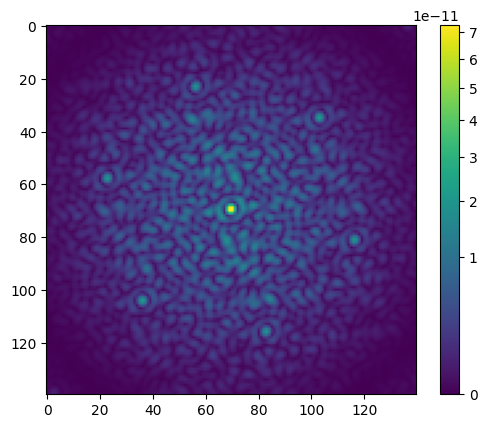

In [11]:
scale = 122 / 7.06  # scaled up for toliman setup
r = 0.147273e-3 * scale  # (m)
mask_coords = (
    np.array(
        [  # (m) SAM-18
            0.569978,
            2.20621,
            -2.22306,
            1.14997,
            -2.49369,
            2.09376,
            1.25201,
            2.91247,
            2.54021,
            -0.110373,
            1.58209,
            -2.86584,
            -2.70485,
            -1.79699,
            2.74591,
            0.869195,
            -2.56407,
            0.796841,
            2.94615,
            -1.45332,
            -0.140611,
            3.24148,
            -1.02159,
            3.03439,
            -1.00524,
            -3.09706,
            -1.68181,
            -0.737597,
            1.10577,
            -2.74708,
            -2.84016,
            -1.32510,
            1.99349,
            -1.21580,
            -1.61688,
            -2.50640,
        ]
    )
    * 1e-3
    * scale
)
mask_coords = np.flip(mask_coords)  # flip x and y for dLux coords convention

mask_coords = mask_coords.reshape(mask_coords.shape[0] // 2, 2)

dynamic_aperture = DynamicAperture(
    subap_centers=[mask_coords],
    rmax=r,
    pixel_coords=coords,
    pattern_rot=240 * np.pi / 180,
    npix=aperture_npix,
    prim_diam=aperture_diameter,
    ap_noll_idxs=np.array([1]),  # piston only
)
sam18_trans = dynamic_aperture.transmission()
layers = [
    (
        "intensity",
        dl.layers.TransmissiveLayer(transmission=intensity_dist, normalise=False),
    ),
    ("sam18", TransmissiveLayer(transmission=sam18_trans, normalise=False)),
    (
        "aperture",
        dl.layers.BasisOptic(
            basis=basis, coefficients=coeffs, transmission=None, normalise=False
        ),
    ),
]
optics_mask = dl.AngularOpticalSystem(
    wf_npixels=wf_npixels,
    diameter=wf_diam,
    layers=layers,
    psf_npixels=140,
    psf_pixel_scale=psf_pixel_scale,
    oversample=oversample,
)


plt.imshow(optics_mask.propagate_mono(red_laser_wl), norm=PowerNorm(0.5))
plt.colorbar()

In [12]:
detector = dl.LayeredDetector([ApplyBFSPixelResponse(pixel_response=jnp.array([0]))])

instrument_bar180 = dl.Telescope(optics=optics_sp180, source=red_src, detector=detector)
instrument_bar270 = dl.Telescope(optics=optics_sp270, source=red_src, detector=detector)
instrument_sam18 = dl.Telescope(
    optics=optics_mask,
    source=(
        "source",
        dl.PointSources(
            wavelengths=[red_laser_wl], flux=jnp.asarray([0.5e16], dtype=float)
        ),
    ),
    detector=detector,
)

In [13]:
params = [
    "aperture.coefficients",
    "spider.rotation",
    # 'sam18.rotation',
    "source.position",
    "source.flux",
    # 'psf_pixel_scale',
    # 'intensity.gauss_param',
]

params_s18 = [
    "aperture.coefficients",
    "sam18.rotation",
    "source.position",
    "source.flux",
    # 'psf_pixel_scale',
]

In [14]:
# Numpyro MCMC samplers expect jax-framework models
n_coeffs = zernike_indicies.shape[0]
params = params_s18


def psf_model(data, model):
    values = [
        npy.sample(
            "aperture.coefficients", dist.Uniform(-100e-9, 100e-9).expand([n_coeffs])
        ),
        npy.sample(
            "sam18.rotation",
            dist.Uniform(-10 * np.pi / 180, 10 * np.pi / 180).expand([1]),
        ),
        npy.sample("source.position", dist.Uniform(-5e-4, 5e-4).expand([1, 2])),
        # npy.sample("source.flux", dist.Uniform(1e15,1e16).expand([1])), # I don't this should be sampled from uniform dist. Flux stored as 1d arr
        npy.sample(
            "source.flux", dist.LogNormal(5e15, 1e15).expand([1])
        ),  # Flux stored as 1d arr
    ]

    with npy.plate("data", len(data.flatten())):
        poisson_model = dist.Poisson(model.set(params, values).model().flatten())
        return npy.sample("psf", poisson_model, obs=data.flatten())

In [15]:
init_flux = jnp.array([5e15])

init_coeffs = jnp.zeros(shape=zernike_indicies.shape)
init_source_pos = jnp.array([[0, 0]])
init_rot = jnp.array([0])

In [ ]:
sampler = npy.infer.MCMC(
    npy.infer.NUTS(
        psf_model,
        forward_mode_differentiation=True,
        init_strategy=npy.infer.initialization.init_to_value(
            values={
                "aperture.coefficients": init_coeffs,
                "source.position": init_source_pos,
                "source.flux": init_flux,
                "sam18.rotation": init_rot,
            }
        ),
    ),
    # npy.infer.NUTS(psf_model, forward_mode_differentiation=True, init_strategy=npy.infer.initialization.init_to_mean()),
    # npy.infer.BarkerMH(psf_model),
    num_warmup=200,
    num_samples=3000,
    num_chains=1,
    progress_bar=True,
)

dummy_data = instrument_sam18.model()
sampler.run(jr.PRNGKey(0), dummy_data, instrument_sam18)

warmup:   0%|          | 7/3200 [01:52<31:55:33, 36.00s/it, 1023 steps of size 1.05e-06. acc. prob=0.06]